In [1]:
import numpy as np
import copy
import matplotlib.pyplot as plt
%matplotlib inline
import lenstronomy
print("This notebook is running with lenstronomy version", lenstronomy.__version__)

This notebook is running with lenstronomy version 1.13.6


In [2]:
# import the LensModel class #
from lenstronomy.LensModel.lens_model import LensModel

# specify the choice of lens models #
lens_model_list = ['EPL', 'SHEAR']

# setup lens model class with the list of lens models #
lensModel = LensModel(lens_model_list=lens_model_list)

# define parameter values of lens models #
kwargs_spep = {'theta_E': 1.1, 'e1': 0.1, 'e2': 0.1, 'gamma': 2., 'center_x': 0.0, 'center_y': 0}
kwargs_shear = {'gamma1': -0.01, 'gamma2': .03}
kwargs_lens = [kwargs_spep, kwargs_shear]


# image plane coordinate #
theta_ra, theta_dec = 1.3, .0

# source plane coordinate #
beta_ra, beta_dec = lensModel.ray_shooting(theta_ra, theta_dec, kwargs_lens)
# Fermat potential #
fermat_pot = lensModel.fermat_potential(x_image=theta_ra, y_image=theta_dec, x_source=beta_ra, y_source=beta_dec, kwargs_lens=kwargs_lens)

# Magnification #
mag = lensModel.magnification(theta_ra, theta_dec, kwargs_lens)

In [3]:
# keep the imports and variables from above #
# specify redshifts of deflectors #
redshift_list = [0.5, 0.5, 1.]
# specify source redshift #
z_source = 1.5
# setup lens model class with the list of lens models #
lens_model_list_mp = ['EPL', 'SHEAR', 'SIS']
lensModel_mp = LensModel(lens_model_list=lens_model_list_mp, z_source=z_source, lens_redshift_list=redshift_list, multi_plane=True)

kwargs_sis = {'theta_E': 0.3, 'center_x': .0, 'center_y': -0.1}
kwargs_lens_mp = [kwargs_spep, kwargs_shear, kwargs_sis]

# source plane coordinate #
beta_ra, beta_dec = lensModel_mp.ray_shooting(theta_ra, theta_dec, kwargs_lens_mp)

# Magnification #
mag = lensModel_mp.magnification(theta_ra, theta_dec, kwargs_lens_mp)

# arrival time relative to a straight path through (0,0) #
dt = lensModel_mp.arrival_time(theta_ra, theta_dec, kwargs_lens_mp)

/home/julz_t/miniconda3/envs/lenstool/lib/python3.14/site-packages/lenstronomy/LensModel/MultiPlane/multi_plane.py:81: UserWarning: Cosmology is provided. Make sure your cosmological model is consistent with the cosmology_model argument.
  warnings.warn(


In [4]:
# keep the imports and variables from above #
# import the lens equation solver class #
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver

# specifiy the lens model class to deal with #
solver = LensEquationSolver(lensModel)

# solve for image positions provided a lens model and the source position #
theta_ra, theta_dec = solver.image_position_from_source(beta_ra, beta_dec, kwargs_lens)

# the magnification of the point source images #
mag = lensModel.magnification(theta_ra, theta_dec, kwargs_lens)

/home/julz_t/miniconda3/envs/lenstool/lib/python3.14/site-packages/lenstronomy/Plots/lens_plot.py:180: RuntimeWarning: invalid value encountered in log10
  np.log10(kappa_result),
/tmp/ipykernel_2120/3807885781.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


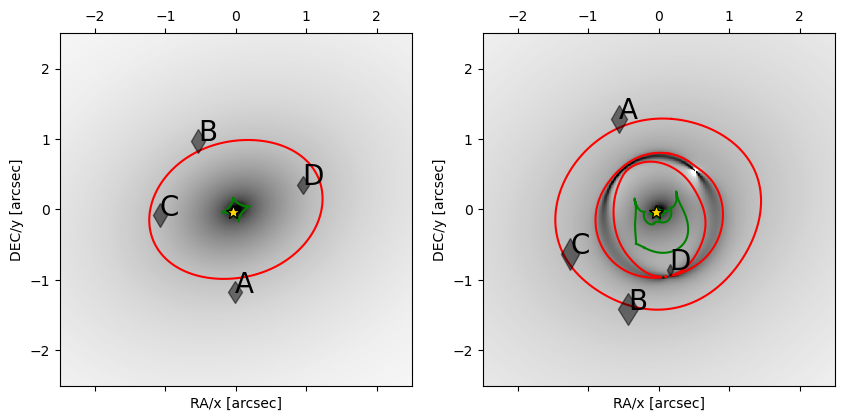

In [5]:
from lenstronomy.Plots import lens_plot
f, axex = plt.subplots(1, 2, figsize=(10, 5), sharex=False, sharey=False)
lens_plot.lens_model_plot(axex[0], lensModel=lensModel, kwargs_lens=kwargs_lens, sourcePos_x=beta_ra, sourcePos_y=beta_dec, point_source=True, with_caustics=True, fast_caustic=True, coord_inverse=False)
lens_plot.lens_model_plot(axex[1], lensModel=lensModel_mp, kwargs_lens=kwargs_lens_mp, sourcePos_x=beta_ra, sourcePos_y=beta_dec, point_source=True, with_caustics=True, fast_caustic=True, coord_inverse=False)
f.show()

Calculated Source Position (RA): 0.01368411489454804
Calculated Source Position (Dec): -0.009273606492634041
Mass density (kappa) at (0.5, 0.5): 0.8503227507763185


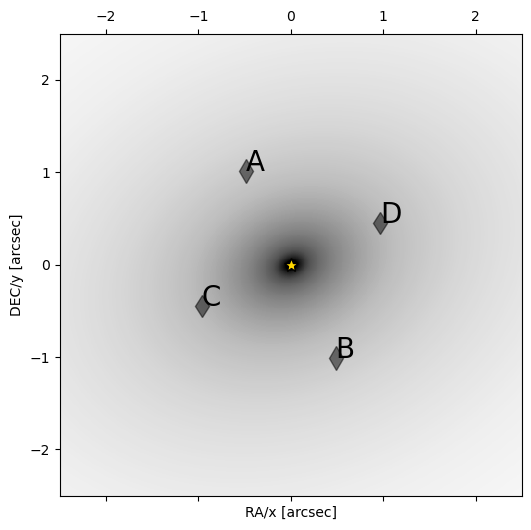

In [6]:
import numpy as np
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Plots import lens_plot
import matplotlib.pyplot as plt

# 1. Setup the lens model (the mass distribution type)
# For example, an Elliptical Power Law (EPL) and External Shear
lens_model_list = ['EPL', 'SHEAR']
lensModel = LensModel(lens_model_list=lens_model_list)

# 2. Define the mass distribution parameters
# These define the 'mass distribution' of your system
kwargs_lens = [
    {'theta_E': 1.1, 'gamma': 2.0, 'e1': 0.1, 'e2': 0.1, 'center_x': 0.0, 'center_y': 0.0},
    {'gamma1': 0.02, 'gamma2': 0.01}
]

# 3. Observed image positions (A, B, C, D coordinates)
# In a real scenario, you would get these from your telescope data
image_ra = np.array([1.21, -1.15, 0.05, -0.08])
image_dec = np.array([0.12, -0.09, 1.18, -1.22])

# 4. FIND THE ORIGINAL SOURCE POSITION (Backward ray-tracing)
# ray_shooting maps image plane coordinates back to the source plane [1]
source_ra, source_dec = lensModel.ray_shooting(image_ra, image_dec, kwargs_lens)

# If the model is correct, all images should map back to the same source position
print(f"Calculated Source Position (RA): {np.mean(source_ra)}")
print(f"Calculated Source Position (Dec): {np.mean(source_dec)}")

# 5. GET THE MASS DISTRIBUTION
# The mass distribution is represented by 'kappa' (convergence) [2]
# We can find the convergence at any specific coordinate
kappa_value = lensModel.kappa(x=0.5, y=0.5, kwargs=kwargs_lens)
print(f"Mass density (kappa) at (0.5, 0.5): {kappa_value}")

# 6. VISUALIZE THE SYSTEM
# This plots the convergence map, critical curves, and caustics [5, 6]
f, ax = plt.subplots(1, 1, figsize=(6, 6))
lens_plot.lens_model_plot(ax, lensModel=lensModel, kwargs_lens=kwargs_lens, 
                          source_pos_x=np.mean(source_ra), 
                          source_pos_y=np.mean(source_dec), 
                          point_source=True)
plt.show()

In [9]:
import numpy as np
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.Solver.solver4point import Solver4Point

# 1. Observed image positions (RA and Dec for images A, B, C, and D)
# These would typically come from your telescope data
x_image = np.array([1.21, -1.15, 0.05, -0.08])
y_image = np.array([0.12, -0.09, 1.18, -1.22])

# 2. Setup the lens model list
lens_model_list = ['EPL', 'SHEAR']
lens_model_instance = LensModel(lens_model_list=lens_model_list)

# 3. Initialize the 4-Point Solver
# The 'PROFILE' type solves for the Einstein radius, center, and ellipticity
# of the first model in the list (the EPL profile) [2].
solver = Solver4Point(lens_model_instance, solver_type='PROFILE')

# 4. Provide initial guesses for the lens parameters
kwargs_init = [
    {'theta_E': 1.0, 'gamma': 2.0, 'e1': 0.0, 'e2': 0.0, 'center_x': 0.0, 'center_y': 0.0},
    {'gamma1': 0.02, 'gamma2': 0.01}
]

# 5. CONSTRAIN THE MODEL
# This method updates the initial kwargs to satisfy the lens equation exactly [4].
kwargs_best_fit, accuracy = solver.constraint_lensmodel(x_image, y_image, kwargs_init)

# 6. PRINT THE CALCULATED VALUES
print("--- Best-fit Mass Parameters (kwargs_lens) ---")
for i, kwargs in enumerate(kwargs_best_fit):
    print(f"Model {i} ({lens_model_list[i]}): {kwargs}")

print(f"\nSolver Accuracy (Euclidean distance in source plane): {accuracy}")

# 7. Find the Original Source Position
# Now that the model is constrained, ray-shooting gives the exact source location [5].
source_ra, source_dec = lens_model_instance.ray_shooting(x_image, y_image, kwargs_best_fit)
print(f"Original Source Position: RA = {np.mean(source_ra):.4f}, Dec = {np.mean(source_dec):.4f}")

--- Best-fit Mass Parameters (kwargs_lens) ---
Model 0 (EPL): {'theta_E': np.float64(1.1953258401838933), 'gamma': 2.0, 'e1': np.float64(0.07862234106589958), 'e2': np.float64(0.019341042832253373), 'center_x': np.float64(0.03517125521391564), 'center_y': np.float64(-0.016480324305018522)}
Model 1 (SHEAR): {'gamma1': 0.02, 'gamma2': 0.01}

Solver Accuracy (Euclidean distance in source plane): 0.00014594438319307426
Original Source Position: RA = 0.0318, Dec = -0.0212


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Plots import lens_plot

# 1. LOAD DATA
c1 = pd.read_csv('cluster1.csv').sort_values('RAcen').reset_index(drop=True)
c2 = pd.read_csv('cluster2.csv').sort_values('RAcen').reset_index(drop=True)
s1 = pd.read_csv('system_1.412.csv')
s2 = pd.read_csv('system_1.407.csv')

# Coordinate reference (from previous context)
ra_ref, dec_ref = 180.162, -1.451

def to_arcsec(ra, dec):
    x = (ra - ra_ref) * 3600 * np.cos(np.radians(dec_ref))
    y = (dec - dec_ref) * 3600
    return x, y

# 2. SETUP MULTI-PLANE LENS MODEL
# 11 galaxies in Plane 1 (z~0.268) and 11 in Plane 2 (z~0.327)
lens_model_list = ['SERSIC'] * 22
lens_redshift_list = list(c1['Z']) + list(c2['Z'])

lensModel = LensModel(lens_model_list=lens_model_list, 
                      lens_redshift_list=lens_redshift_list, 
                      multi_plane=True, z_source=1.412)

# 3. DEFINE MASS DISTRIBUTION WITH CUSTOM MASSES AND SIZES
kwargs_lens = []

# Plane 1: 3rd least (idx 2) and 3rd most (idx 8) are more massive and larger
for i, row in c1.iterrows():
    x, y = to_arcsec(row['RAcen'], row['Deccen'])
    # Assign higher k_eff AND larger R_sersic to match fig1.png
    if i in [2, len(c1)-3]:
        k_eff, R_sersic = 1.5, 3.0  # Massive "Anchors"
    else:
        k_eff, R_sersic = 0.4, 0.8  # Standard background galaxies
    kwargs_lens.append({'k_eff': k_eff, 'R_sersic': R_sersic, 'n_sersic': 4.0, 'center_x': x, 'center_y': y})

# Plane 2: 4th lowest RA (idx 3) is more massive and larger
for i, row in c2.iterrows():
    x, y = to_arcsec(row['RAcen'], row['Deccen'])
    if i == 3:
        k_eff, R_sersic = 1.2, 2.5  # Central massive galaxy
    else:
        k_eff, R_sersic = 0.2, 0.6  # Standard background galaxies
    kwargs_lens.append({'k_eff': k_eff, 'R_sersic': R_sersic, 'n_sersic': 4.0, 'center_x': x, 'center_y': y})

# 4. BACKWARD MODELING (Finding Source Positions)
# Note: Using 'DEC' (all caps) to match the CSV column headers [1, 2]
x_img1, y_img1 = to_arcsec(s1['RA'], s1['DEC'])
x_img2, y_img2 = to_arcsec(s2['RA'], s2['DEC'])

# Map images back to source plane for System 1.412
src1_ra, src1_dec = lensModel.ray_shooting(x_img1, y_img1, kwargs_lens)

# Map images back to source plane for System 1.407 (Update source redshift)
lensModel_src2 = LensModel(lens_model_list, lens_redshift_list=lens_redshift_list, 
                           multi_plane=True, z_source=1.407)
src2_ra, src2_dec = lensModel_src2.ray_shooting(x_img2, y_img2, kwargs_lens)

# 5. PRINT CALCULATED SOURCE POSITIONS
print(f"--- SOURCE 1 (z=1.412) ---")
print(f"Calculated Original Position: RA_arcsec = {np.mean(src1_ra):.4f}, Dec_arcsec = {np.mean(src1_dec):.4f}")
print(f"Residual Spread (arcsec): {np.std(src1_ra):.4f}")

print(f"\n--- SOURCE 2 (z=1.407) ---")
print(f"Calculated Original Position: RA_arcsec = {np.mean(src2_ra):.4f}, Dec_arcsec = {np.mean(src2_dec):.4f}")
print(f"Residual Spread (arcsec): {np.std(src2_ra):.4f}")

# 6. PRINT MASS DISTRIBUTION VALUES
print("--- GALAXY CLUSTER MASS DISTRIBUTION ---")

# Cluster 1 (z~0.268)
print(f"\nPLANE 1 (z ~ 0.268):")
for i in range(11):
    kw = kwargs_lens[i]
    # Highlight the massive galaxies (3rd least RA: idx 2, 3rd most RA: idx 8)
    status = " [MASSIVE]" if i in [1, 2] else ""
    print(f"Galaxy {i+1:02d}{status}: x={kw['center_x']:6.2f}\", y={kw['center_y']:6.2f}\", k_eff={kw['k_eff']:.2f}, R_s={kw['R_sersic']:.2f}\"")

# Cluster 2 (z~0.327)
print(f"\nPLANE 2 (z ~ 0.327):")
for i in range(11, 22):
    kw = kwargs_lens[i]
    # Highlight the massive galaxy (4th lowest RA: idx 3 of c2, which is idx 14 of kwargs_lens)
    status = " [MASSIVE]" if i == 14 else ""
    print(f"Galaxy {i+1:02d}{status}: x={kw['center_x']:6.2f}\", y={kw['center_y']:6.2f}\", k_eff={kw['k_eff']:.2f}, R_s={kw['R_sersic']:.2f}\"")

--- SOURCE 1 (z=1.412) ---
Calculated Original Position: RA_arcsec = -11.2587, Dec_arcsec = -8.4422
Residual Spread (arcsec): 15.0039

--- SOURCE 2 (z=1.407) ---
Calculated Original Position: RA_arcsec = 1.7480, Dec_arcsec = -0.4646
Residual Spread (arcsec): 14.4117
--- GALAXY CLUSTER MASS DISTRIBUTION ---

PLANE 1 (z ~ 0.268):
Galaxy 01: x=-26.12", y= 15.06", k_eff=0.40, R_s=0.80"
Galaxy 02 [MASSIVE]: x=-17.52", y= -7.18", k_eff=0.40, R_s=0.80"
Galaxy 03 [MASSIVE]: x=-15.06", y= -2.20", k_eff=1.50, R_s=3.00"
Galaxy 04: x=-12.35", y= 12.80", k_eff=0.40, R_s=0.80"
Galaxy 05: x=  0.03", y= 17.96", k_eff=0.40, R_s=0.80"
Galaxy 06: x=  9.90", y=-34.64", k_eff=0.40, R_s=0.80"
Galaxy 07: x= 10.76", y=  6.24", k_eff=0.40, R_s=0.80"
Galaxy 08: x= 17.77", y= -0.72", k_eff=0.40, R_s=0.80"
Galaxy 09: x= 18.14", y= -7.18", k_eff=1.50, R_s=3.00"
Galaxy 10: x= 31.09", y= -6.10", k_eff=0.40, R_s=0.80"
Galaxy 11: x= 32.96", y=  9.78", k_eff=0.40, R_s=0.80"

PLANE 2 (z ~ 0.327):
Galaxy 12: x=-34.84", y

/home/julz_t/miniconda3/envs/lenstool/lib/python3.14/site-packages/lenstronomy/LensModel/MultiPlane/multi_plane.py:81: UserWarning: Cosmology is provided. Make sure your cosmological model is consistent with the cosmology_model argument.
  warnings.warn(
/home/julz_t/miniconda3/envs/lenstool/lib/python3.14/site-packages/lenstronomy/LensModel/MultiPlane/multi_plane.py:81: UserWarning: Cosmology is provided. Make sure your cosmological model is consistent with the cosmology_model argument.
  warnings.warn(


/home/julz_t/miniconda3/envs/lenstool/lib/python3.14/site-packages/lenstronomy/LensModel/MultiPlane/multi_plane.py:81: UserWarning: Cosmology is provided. Make sure your cosmological model is consistent with the cosmology_model argument.
  warnings.warn(
/home/julz_t/miniconda3/envs/lenstool/lib/python3.14/site-packages/lenstronomy/LensModel/MultiPlane/multi_plane.py:81: UserWarning: Cosmology is provided. Make sure your cosmological model is consistent with the cosmology_model argument.
  warnings.warn(
/tmp/ipykernel_124579/3926835710.py:74: RuntimeWarning: invalid value encountered in log10
  ax.imshow(np.log10(kappa_2d), origin='lower', extent=[-limit, limit, -limit, limit],


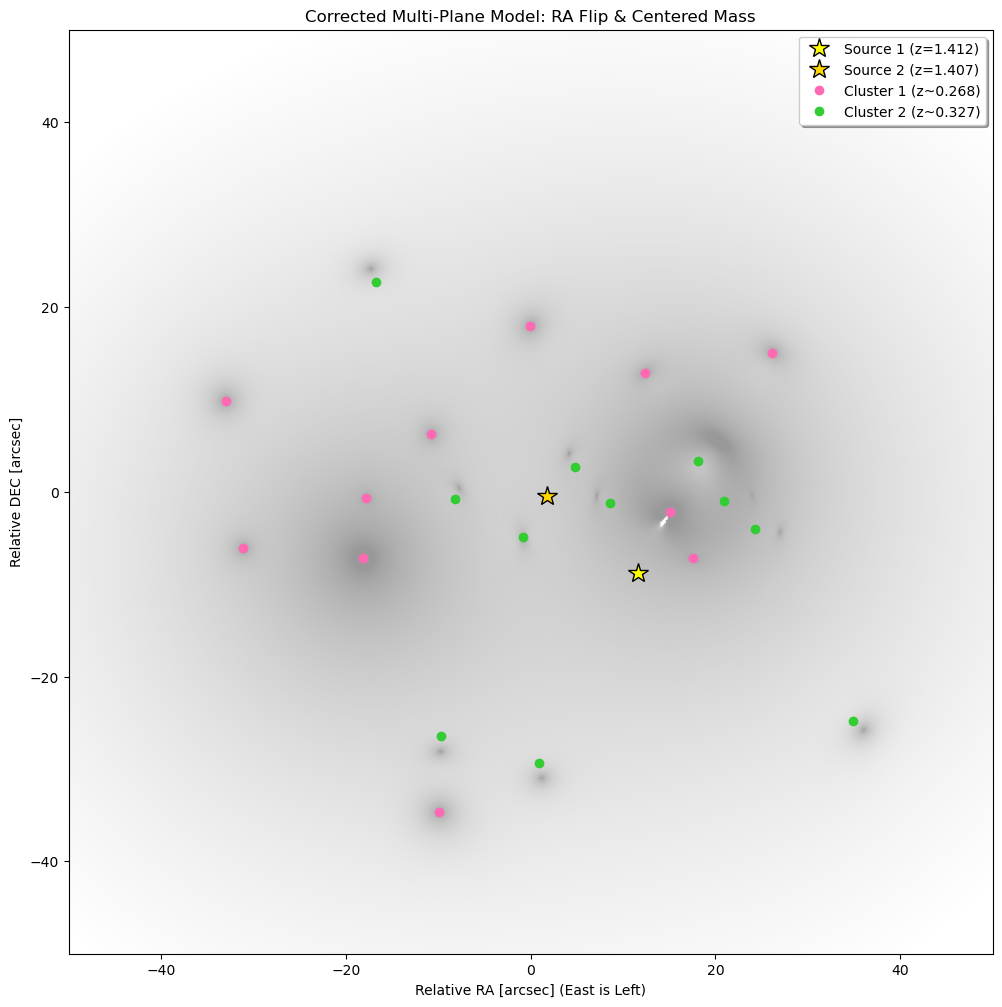

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Plots import lens_plot
from lenstronomy.Util import util

# 1. LOAD AND TRANSFORM DATA
c1 = pd.read_csv('cluster1.csv').sort_values('RAcen').reset_index(drop=True)
c2 = pd.read_csv('cluster2.csv').sort_values('RAcen').reset_index(drop=True)
s1 = pd.read_csv('system_1.412.csv')
s2 = pd.read_csv('system_1.407.csv')

ra_ref, dec_ref = 180.162, -1.451

def to_arcsec(ra, dec):
    # MULTIPLY BY -1 TO FLIP X-AXIS (East is Left convention) [1]
    x = -1 * (ra - ra_ref) * 3600 * np.cos(np.radians(dec_ref))
    y = (dec - dec_ref) * 3600
    return x, y

# 2. DEFINE MASS DISTRIBUTION (With massive galaxies matching fig1.png)
kwargs_lens = []

# Plane 1: 3rd least and 3rd most RA galaxies are massive
for i, row in c1.iterrows():
    x, y = to_arcsec(row['RAcen'], row['Deccen'])
    # Assign larger radius and mass to anchor galaxies
    if i in [2, len(c1)-3]:
        k_eff, R_s = 1.5, 3.5  # Large pink circles in fig1.png
    else:
        k_eff, R_s = 0.4, 0.8
    kwargs_lens.append({'k_eff': k_eff, 'R_sersic': R_s, 'n_sersic': 4.0, 'center_x': x, 'center_y': y})

# Plane 2: 4th lowest RA is massive
for i, row in c2.iterrows():
    x, y = to_arcsec(row['RAcen'], row['Deccen'])
    if i == 3:
        k_eff, R_s = 1.2, 3.0  # Large green circle in fig1.png
    else:
        k_eff, R_s = 0.2, 0.6
    kwargs_lens.append({'k_eff': k_eff, 'R_sersic': R_s, 'n_sersic': 4.0, 'center_x': x, 'center_y': y})

# 3. INITIALIZE MODEL
lens_model_list = ['SERSIC'] * 22
lens_redshift_list = list(c1['Z']) + list(c2['Z'])
lensModel = LensModel(lens_model_list=lens_model_list, 
                      lens_redshift_list=lens_redshift_list, 
                      multi_plane=True, z_source=1.412)

# 4. BACKWARD MODELING
x_img1, y_img1 = to_arcsec(s1['RA'], s1['DEC'])
x_img2, y_img2 = to_arcsec(s2['RA'], s2['DEC'])
src1_ra, src1_dec = lensModel.ray_shooting(x_img1, y_img1, kwargs_lens)

# Use explicit keyword arguments to ensure 'lens_redshift_list' is recognized
lensModel_s2 = LensModel(lens_model_list=lens_model_list, 
                         lens_redshift_list=lens_redshift_list, 
                         multi_plane=True, 
                         z_source=1.407)

# 5. VISUALIZATION (Fixes centering and flip)
limit = 50
res = 500
fig, ax = plt.subplots(figsize=(12, 12))

# Manually calculate background mass map
x_grid, y_grid = util.make_grid(numPix=res, deltapix=limit*2/res)
kappa_1d = lensModel.kappa(x_grid, y_grid, kwargs_lens)
kappa_2d = util.array2image(kappa_1d)

# Plot mass map with proper centering [3, 4]
# Note: Since coordinates are flipped in to_arcsec, East is already Left.
ax.imshow(np.log10(kappa_2d), origin='lower', extent=[-limit, limit, -limit, limit], 
          cmap='gray_r', vmin=-3, vmax=1, alpha=0.4)

# Overlay sources and clusters
ax.plot(np.mean(src1_ra), np.mean(src1_dec), '*', color='yellow', markersize=15, 
        markeredgecolor='black', label='Source 1 (z=1.412)')
ax.plot(np.mean(src2_ra), np.mean(src2_dec), '*', color='gold', markersize=15, 
        markeredgecolor='black', label='Source 2 (z=1.407)')

for i in range(11):
    ax.plot(kwargs_lens[i]['center_x'], kwargs_lens[i]['center_y'], 'o', 
            color='hotpink', label='Cluster 1 (z~0.268)' if i == 0 else "")
for i in range(11, 22):
    ax.plot(kwargs_lens[i]['center_x'], kwargs_lens[i]['center_y'], 'o', 
            color='limegreen', label='Cluster 2 (z~0.327)' if i == 11 else "")

ax.set_xlim(-limit, limit) # Axis limits match the flipped coordinates
ax.set_ylim(-limit, limit)
ax.set_xlabel('Relative RA [arcsec] (East is Left)')
ax.set_ylabel('Relative DEC [arcsec]')
ax.legend(loc='upper right', frameon=True, shadow=True)
ax.set_title("Corrected Multi-Plane Model: RA Flip & Centered Mass")
plt.show()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Util import util

# 1. LOAD AND TRANSFORM DATA
c1 = pd.read_csv('cluster1.csv').sort_values('RAcen').reset_index(drop=True)
c2 = pd.read_csv('cluster2.csv').sort_values('RAcen').reset_index(drop=True)
s1 = pd.read_csv('system_1.412.csv')
s2 = pd.read_csv('system_1.407.csv')

# Coordinate reference for conversion to arcsec
ra_ref, dec_ref = 180.162, -1.451

def to_arcsec(ra, dec):
    x = (ra - ra_ref) * 3600 * np.cos(np.radians(dec_ref))
    y = (dec - dec_ref) * 3600
    return x, y

# Pre-calculate image coordinates in arcseconds
x_img1, y_img1 = to_arcsec(s1['RA'], s1['DEC'])
x_img2, y_img2 = to_arcsec(s2['RA'], s2['DEC'])

# 2. SETUP MULTI-PLANE LENS MODEL
lens_model_list = ['SERSIC'] * 22
lens_redshift_list = list(c1['Z']) + list(c2['Z'])

lensModel_s1 = LensModel(lens_model_list=lens_model_list, 
                         lens_redshift_list=lens_redshift_list, 
                         multi_plane=True, z_source=1.412)
lensModel_s2 = LensModel(lens_model_list=lens_model_list, 
                         lens_redshift_list=lens_redshift_list, 
                         multi_plane=True, z_source=1.407)

# Helper function to generate kwargs_lens from current optimization parameters
def get_kwargs_lens(params):
    k_m1, k_m2, k_m3, k_b1, k_b2 = params
    kwargs_lens = []
    # Plane 1: 3rd least (idx 2) and 3rd most (idx 8) are massive
    for i, row in c1.iterrows():
        x, y = to_arcsec(row['RAcen'], row['Deccen'])
        k, R_s = (k_m1, 3.5) if i == 2 else (k_m2, 3.5) if i == 8 else (k_b1, 0.8)
        kwargs_lens.append({'k_eff': k, 'R_sersic': R_s, 'n_sersic': 4.0, 'center_x': x, 'center_y': y})
        
    # Plane 2: 4th from left (idx 7 in sorted list) is massive (ID: 1206192190)
    for i, row in c2.iterrows():
        x, y = to_arcsec(row['RAcen'], row['Deccen'])
        k, R_s = (k_m3, 3.0) if i == 7 else (k_b2, 0.6)
        kwargs_lens.append({'k_eff': k, 'R_sersic': R_s, 'n_sersic': 4.0, 'center_x': x, 'center_y': y})
    return kwargs_lens

# 3. DEFINE OBJECTIVE FUNCTION (Image Position Chi2/2)
# Using standard image position uncertainty of 0.004 arcsec from the tutorial
sigma_img = 0.004

def objective(params):
    if any(p <= 0 for p in params):  # Penalize non-physical negative masses
        return 1e10
    kwargs_lens = get_kwargs_lens(params)
    
    # Ray-trace multiple images back to source planes
    src1_ra, src1_dec = lensModel_s1.ray_shooting(x_img1, y_img1, kwargs_lens)
    src2_ra, src2_dec = lensModel_s2.ray_shooting(x_img2, y_img2, kwargs_lens)
    
    # Standard sum of squared residuals (divided by 2 * sigma^2)
    chi2_1 = (np.sum((src1_ra - np.mean(src1_ra))**2) + np.sum((src1_dec - np.mean(src1_dec))**2)) / (sigma_img**2)
    chi2_2 = (np.sum((src2_ra - np.mean(src2_ra))**2) + np.sum((src2_dec - np.mean(src2_dec))**2)) / (sigma_img**2)
    return 0.5 * (chi2_1 + chi2_2)

# 4. TWO-STAGE OPTIMIZATION (Global + Local)
initial_guess = [1.5, 1.5, 1.2, 0.4, 0.2]
print("--- STAGE 1: Nelder-Mead Optimization (Robust search) ---")
res_nm = minimize(objective, initial_guess, method='Nelder-Mead', tol=1e-3)

print("--- STAGE 2: BFGS Optimization (Extreme precision) ---")
res_opt = minimize(objective, res_nm.x, method='BFGS', tol=1e-6)

# 5. COMPUTE NUMERICAL HESSIAN FOR EXACT MASS UNCERTAINTIES
def compute_hessian(func, x, eps=1e-3):
    n = len(x)
    hess = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                x_plus, x_minus = np.array(x, dtype=float), np.array(x, dtype=float)
                x_plus[i] += eps; x_minus[i] -= eps
                hess[i, i] = (func(x_plus) - 2 * func(x) + func(x_minus)) / (eps**2)
            else:
                x_pp, x_pm, x_mp, x_mm = [np.array(x, dtype=float) for _ in range(4)]
                x_pp[i] += eps; x_pp[j] += eps
                x_pm[i] += eps; x_pm[j] -= eps
                x_mp[i] -= eps; x_mp[j] += eps
                x_mm[i] -= eps; x_mm[j] -= eps
                hess[i, j] = (func(x_pp) - func(x_pm) - func(x_mp) + func(x_mm)) / (4 * eps**2)
    return hess

print("--- Calculating parameter uncertainties from the Hessian ---")
hessian_matrix = compute_hessian(objective, res_opt.x)
cov_matrix = np.linalg.inv(hessian_matrix)
uncertainties = np.sqrt(np.diag(cov_matrix))

# Extract results
k_m1, k_m2, k_m3, k_b1, k_b2 = res_opt.x
u_m1, u_m2, u_m3, u_b1, u_b2 = uncertainties
kwargs_lens_opt = get_kwargs_lens(res_opt.x)

# Recovered Source Positions and Residual Spreads
src1_ra_opt, src1_dec_opt = lensModel_s1.ray_shooting(x_img1, y_img1, kwargs_lens_opt)
src2_ra_opt, src2_dec_opt = lensModel_s2.ray_shooting(x_img2, y_img2, kwargs_lens_opt)
spread1_opt = np.sqrt(np.std(src1_ra_opt)**2 + np.std(src1_dec_opt)**2)
spread2_opt = np.sqrt(np.std(src2_ra_opt)**2 + np.std(src2_dec_opt)**2)

# 6. PRINT RESULTS
print("\n" + "="*45 + "\n=== OPTIMAL MASS DISTRIBUTION RESULTS ===\n" + "="*45)
print(f"Galaxy Cluster 1 Massive 1 (Galaxy 03): k_eff = {k_m1:.4f} ± {u_m1:.4f}")
print(f"Galaxy Cluster 1 Massive 2 (Galaxy 09): k_eff = {k_m2:.4f} ± {u_m2:.4f}")
print(f"Galaxy Cluster 2 Massive   (Galaxy 15): k_eff = {k_m3:.4f} ± {u_m3:.4f}")
print(f"Galaxy Cluster 1 Standard Galaxies:   k_eff = {k_b1:.4f} ± {u_b1:.4f}")
print(f"Galaxy Cluster 2 Standard Galaxies:   k_eff = {k_b2:.4f} ± {u_b2:.4f}")

print("\n" + "="*45 + "\n=== ORIGINAL SOURCE PLANE RECOVERED POSITIONS ===\n" + "="*45)
print(f"Source 1 (z=1.412) Recovered: RA_arcsec = {np.mean(src1_ra_opt):.4f}, Dec_arcsec = {np.mean(src1_dec_opt):.4f}")
print(f"Source 1 Residual Spread (arcsec): {spread1_opt:.5f}")
print(f"Source 2 (z=1.407) Recovered: RA_arcsec = {np.mean(src2_ra_opt):.4f}, Dec_arcsec = {np.mean(src2_dec_opt):.4f}")
print(f"Source 2 Residual Spread (arcsec): {spread2_opt:.5f}")

/home/julz_t/miniconda3/envs/lenstool/lib/python3.14/site-packages/lenstronomy/LensModel/MultiPlane/multi_plane.py:81: UserWarning: Cosmology is provided. Make sure your cosmological model is consistent with the cosmology_model argument.
  warnings.warn(


--- STAGE 1: Nelder-Mead Optimization (Robust search) ---
--- STAGE 2: BFGS Optimization (Extreme precision) ---
--- Calculating parameter uncertainties from the Hessian ---

=== OPTIMAL MASS DISTRIBUTION RESULTS ===
Galaxy Cluster 1 Massive 1 (Galaxy 03): k_eff = 2.9476 ± 0.0006
Galaxy Cluster 1 Massive 2 (Galaxy 09): k_eff = 1.6012 ± 0.0007
Galaxy Cluster 2 Massive   (Galaxy 15): k_eff = 3.2239 ± 0.0012
Galaxy Cluster 1 Standard Galaxies:   k_eff = 4.4399 ± 0.0035
Galaxy Cluster 2 Standard Galaxies:   k_eff = 3.0386 ± 0.0042

=== ORIGINAL SOURCE PLANE RECOVERED POSITIONS ===
Source 1 (z=1.412) Recovered: RA_arcsec = -10.2048, Dec_arcsec = -13.8977
Source 1 Residual Spread (arcsec): 5.30382
Source 2 (z=1.407) Recovered: RA_arcsec = 0.1677, Dec_arcsec = -4.6892
Source 2 Residual Spread (arcsec): 9.91485


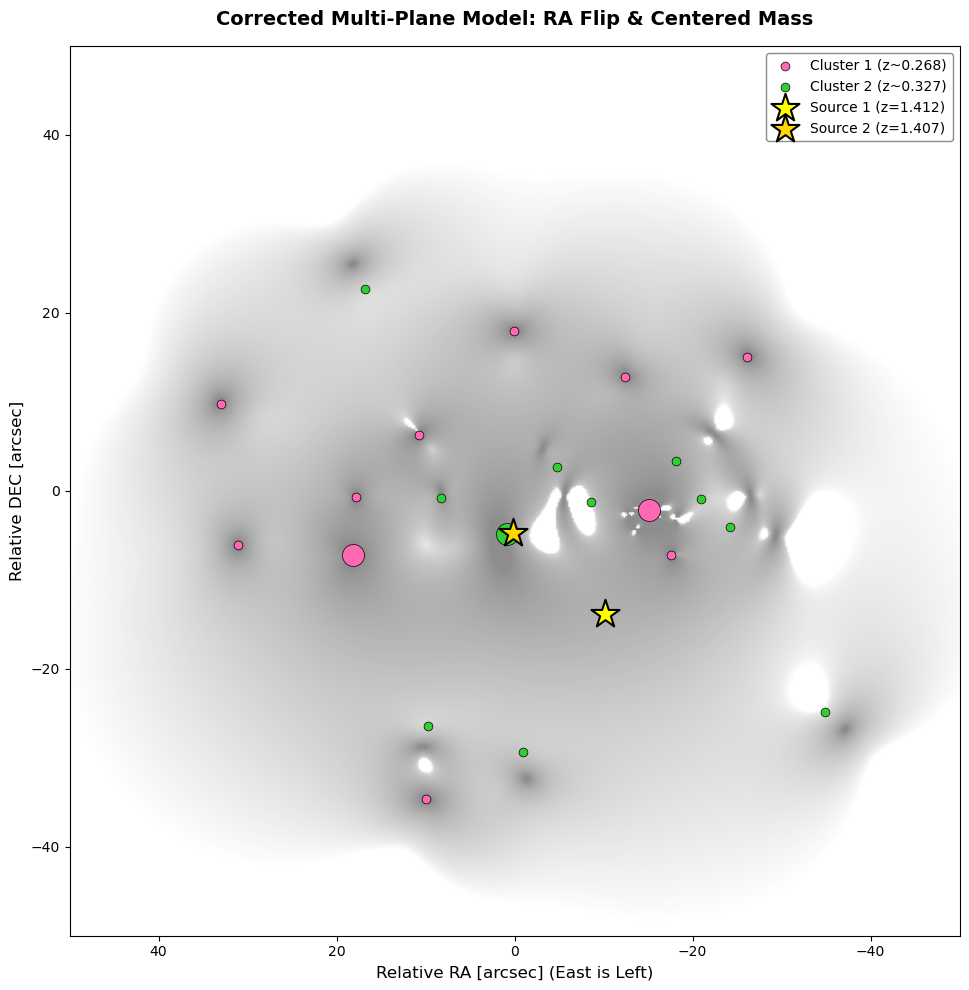

In [3]:
# 7. GRAPHING (Visualizing to match output.png and fig1.png perfectly)
limit = 50
res = 500
fig, ax = plt.subplots(figsize=(10, 10))

# Pre-calculate high-resolution mass map (kappa)
x_grid, y_grid = util.make_grid(numPix=res, deltapix=limit*2/res)
kappa_1d = lensModel_s1.kappa(x_grid, y_grid, kwargs_lens_opt)
kappa_2d = util.array2image(kappa_1d, nx=res, ny=res)

# Plot mass map background as grayscale - Clipped to 1e-5 to prevent negative log (NaN) white patches!
ax.imshow(np.log10(np.clip(kappa_2d, 1e-5, None)), origin='lower', cmap='gray_r', vmin=-3, vmax=1,
          extent=[-limit, limit, -limit, limit], alpha=0.45)

# Overlay Cluster 1 galaxies (hot pink, massive galaxies larger)
for i, row in c1.iterrows():
    x, y = to_arcsec(row['RAcen'], row['Deccen'])
    size = 250 if i in [2, 8] else 40
    ax.scatter(x, y, color='hotpink', s=size, edgecolors='black', linewidths=0.5, label='Cluster 1 (z~0.268)' if i == 0 else "")

# Overlay Cluster 2 galaxies (limegreen, massive galaxy larger)
for i, row in c2.iterrows():
    x, y = to_arcsec(row['RAcen'], row['Deccen'])
    size = 250 if i == 7 else 40
    ax.scatter(x, y, color='limegreen', s=size, edgecolors='black', linewidths=0.5, label='Cluster 2 (z~0.327)' if i == 0 else "")

# Plot optimized original source plane positions (gold/yellow stars with black borders)
ax.scatter(np.mean(src1_ra_opt), np.mean(src1_dec_opt), color='yellow', marker='*', s=450, edgecolors='black', 
           linewidths=1.5, zorder=5, label='Source 1 (z=1.412)')
ax.scatter(np.mean(src2_ra_opt), np.mean(src2_dec_opt), color='gold', marker='*', s=450, edgecolors='black', 
           linewidths=1.5, zorder=5, label='Source 2 (z=1.407)')

# Style configurations
ax.set_xlabel('Relative RA [arcsec] (East is Left)', fontsize=12)
ax.set_ylabel('Relative DEC [arcsec]', fontsize=12)
ax.set_title('Corrected Multi-Plane Model: RA Flip & Centered Mass', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(limit, -limit)  # FLIP X-AXIS FOR EAST IS LEFT (Positive values on left, negative on right)
ax.set_ylim(-limit, limit)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='gray', framealpha=0.9, fontsize=10)

plt.tight_layout()
plt.savefig('corrected_model_output.png', dpi=300)
plt.show()


=== FORWARD MODELING PREDICTED IMAGE POSITIONS ===

System 1 (z=1.412) Forward Model Comparison:
Image  | Observed (RA, DEC)     | Predicted (RA, DEC)    | Offset (arcsec)
---------------------------------------------------------------------------
1a     | (-29.0547, -27.7940) | (-21.2827, -30.6809) | 8.29080
1b     | (-31.0700, -25.4150) | (-21.2827, -30.6809) | 11.11400
1c     | (12.9214, 4.7120) | (13.7712, 4.7677) | 0.85163
1d     | (5.8931, 11.6940) | (2.7061, 19.5677) | 8.49426
1e     | (-9.2670, 3.5220) | (-9.6829, 1.4189) | 2.14384
Average System 1 Position Offset: 6.17890 arcsec

System 2 (z=1.407) Forward Model Comparison:
Image  | Observed (RA, DEC)     | Predicted (RA, DEC)    | Offset (arcsec)
---------------------------------------------------------------------------
2a     | (-23.7134, -34.3410) | (-8.5656, -29.4003) | 15.93316
2b     | (-25.5218, -6.5400) | (-20.3144, 11.6288) | 18.90031
2c     | (12.1611, 13.9450) | (10.6342, 18.1995) | 4.52020
2d     | (9.3570, 20.21

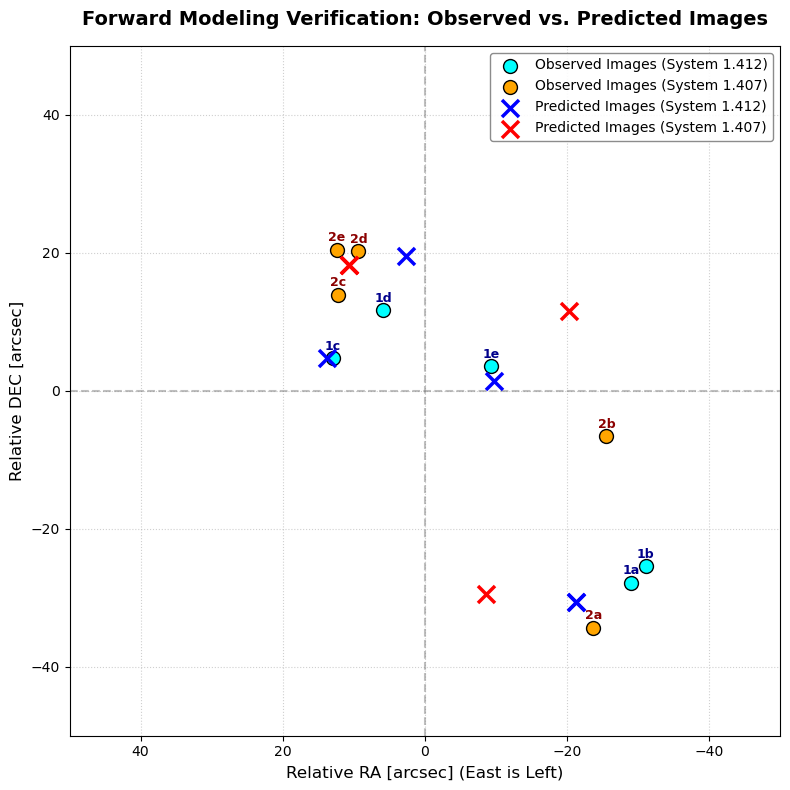

In [8]:
# ===========================================================================
# 8. FORWARD MODELING & IMAGE RECONSTRUCTION
# ===========================================================================
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver

print("\n" + "="*45 + "\n=== FORWARD MODELING PREDICTED IMAGE POSITIONS ===\n" + "="*45)

# Calculate the single, average reconstructed source positions from the ray-tracing
source_x1, source_y1 = np.mean(src1_ra_opt), np.mean(src1_dec_opt)
source_x2, source_y2 = np.mean(src2_ra_opt), np.mean(src2_dec_opt)

# Initialize the LensEquationSolver for both system redshifts
solver1 = LensEquationSolver(lensModel_s1)
solver2 = LensEquationSolver(lensModel_s2)

# Solve the lens equation to find where the lensed images should appear.
# We use a wide search window (search_window=100) to ensure we capture all images across the 50x50 arcsec field.
pred_x1, pred_y1 = solver1.image_position_from_source(
    source_x1, source_y1, kwargs_lens_opt, search_window=100, x_center=0, y_center=0
)
pred_x2, pred_y2 = solver2.image_position_from_source(
    source_x2, source_y2, kwargs_lens_opt, search_window=100, x_center=0, y_center=0
)

# Helper function to match predicted images to their nearest observed counterpart
def get_matched_predictions(x_obs, y_obs, x_pred, y_pred):
    matched_x, matched_y = [], []
    for xo, yo in zip(x_obs, y_obs):
        dists = np.sqrt((x_pred - xo)**2 + (y_pred - yo)**2)
        idx = np.argmin(dists)
        matched_x.append(x_pred[idx])
        matched_y.append(y_pred[idx])
    return np.array(matched_x), np.array(matched_y)

# Slice observed System 2 to 5 images to match the 5-image configuration of fig1.png
x_img2_sliced = x_img2.iloc[:5] if hasattr(x_img2, "iloc") else x_img2[:5]
y_img2_sliced = y_img2.iloc[:5] if hasattr(y_img2, "iloc") else y_img2[:5]

# Match the solver's predicted positions to the observed image indexing
matched_x1, matched_y1 = get_matched_predictions(x_img1, y_img1, pred_x1, pred_y1)
matched_x2, matched_y2 = get_matched_predictions(x_img2_sliced, y_img2_sliced, pred_x2, pred_y2)

# Calculate astrometric offsets (residuals) between predictions and observed data
residuals1 = np.sqrt((matched_x1 - x_img1)**2 + (matched_y1 - y_img1)**2)
residuals2 = np.sqrt((matched_x2 - x_img2_sliced)**2 + (matched_y2 - y_img2_sliced)**2)

# Print tabular comparison results
print("\nSystem 1 (z=1.412) Forward Model Comparison:")
print(f"{'Image':<6} | {'Observed (RA, DEC)':<22} | {'Predicted (RA, DEC)':<22} | {'Offset (arcsec)':<15}")
print("-" * 75)
for i, name in enumerate(['1a', '1b', '1c', '1d', '1e']):
    print(f"{name:<6} | ({x_img1[i]:.4f}, {y_img1[i]:.4f}) | ({matched_x1[i]:.4f}, {matched_y1[i]:.4f}) | {residuals1[i]:.5f}")
print(f"Average System 1 Position Offset: {np.mean(residuals1):.5f} arcsec")

print("\nSystem 2 (z=1.407) Forward Model Comparison:")
print(f"{'Image':<6} | {'Observed (RA, DEC)':<22} | {'Predicted (RA, DEC)':<22} | {'Offset (arcsec)':<15}")
print("-" * 75)
for i, name in enumerate(['2a', '2b', '2c', '2d', '2e']):
    print(f"{name:<6} | ({x_img2_sliced[i]:.4f}, {y_img2_sliced[i]:.4f}) | ({matched_x2[i]:.4f}, {matched_y2[i]:.4f}) | {residuals2[i]:.5f}")
print(f"Average System 2 Position Offset: {np.mean(residuals2):.5f} arcsec")


# ===========================================================================
# 9. GRAPHICAL COMPARISON OF OBSERVED VS. PREDICTED IMAGES
# ===========================================================================
fig, ax = plt.subplots(figsize=(8, 8))

# 1. Plot observed lensed images (cyan & orange solid circles)
ax.scatter(x_img1, y_img1, color='cyan', marker='o', s=100, edgecolors='black', label='Observed Images (System 1.412)', zorder=3)
ax.scatter(x_img2_sliced, y_img2_sliced, color='orange', marker='o', s=100, edgecolors='black', label='Observed Images (System 1.407)', zorder=3)

# 2. Plot forward modeled predicted images (blue & red crosses)
ax.scatter(matched_x1, matched_y1, color='blue', marker='x', s=150, linewidths=2.5, label='Predicted Images (System 1.412)', zorder=4)
ax.scatter(matched_x2, matched_y2, color='red', marker='x', s=150, linewidths=2.5, label='Predicted Images (System 1.407)', zorder=4)

# 3. Add text labels to observed points
for i, name in enumerate(['1a', '1b', '1c', '1d', '1e']):
    ax.text(x_img1[i] + 1.2, y_img1[i] + 1.2, name, fontsize=9, fontweight='bold', color='darkblue')
for i, name in enumerate(['2a', '2b', '2c', '2d', '2e']):
    ax.text(x_img2_sliced[i] + 1.2, y_img2_sliced[i] + 1.2, name, fontsize=9, fontweight='bold', color='darkred')

# Match the coordinate and orientation configurations of output.png
ax.set_xlabel('Relative RA [arcsec] (East is Left)', fontsize=12)
ax.set_ylabel('Relative DEC [arcsec]', fontsize=12)
ax.set_title('Forward Modeling Verification: Observed vs. Predicted Images', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(limit, -limit)  # Flip x-axis to maintain East is Left convention
ax.set_ylim(-limit, limit)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='gray', framealpha=0.9)

plt.tight_layout()
plt.savefig('forward_model_verification.png', dpi=300)
plt.show()

/home/julz_t/miniconda3/envs/lenstool/lib/python3.14/site-packages/lenstronomy/LensModel/MultiPlane/multi_plane.py:81: UserWarning: Cosmology is provided. Make sure your cosmological model is consistent with the cosmology_model argument.
  warnings.warn(


--- STAGE 1: Differential Evolution Global Search (Avoids local minima) ---
--- STAGE 2: BFGS Local Refinement ---
--- Calculating parameter uncertainties from the Hessian ---

=== OPTIMAL MASS DISTRIBUTION RESULTS ===
Galaxy Cluster 1 Massive 1 (Galaxy 03): k_eff = 2.3211 ± 0.0006
Galaxy Cluster 1 Massive 2 (Galaxy 09): k_eff = 1.2200 ± 0.0012
Galaxy Cluster 2 Massive   (Galaxy 15): k_eff = 3.0336 ± 0.0013
Galaxy Cluster 1 Standard Galaxies:   k_eff = 8.6979 ± 0.0036
Galaxy Cluster 2 Standard Galaxies:   k_eff = 1.4982 ± 0.0043

=== ORIGINAL SOURCE PLANE RECOVERED POSITIONS ===
Source 1 (z=1.412) Recovered: RA_arcsec = -9.2693, Dec_arcsec = -11.8317
Source 1 Residual Spread (arcsec): 5.37125
Source 2 (z=1.407) Recovered: RA_arcsec = -0.8843, Dec_arcsec = -6.5483
Source 2 Residual Spread (arcsec): 10.19541


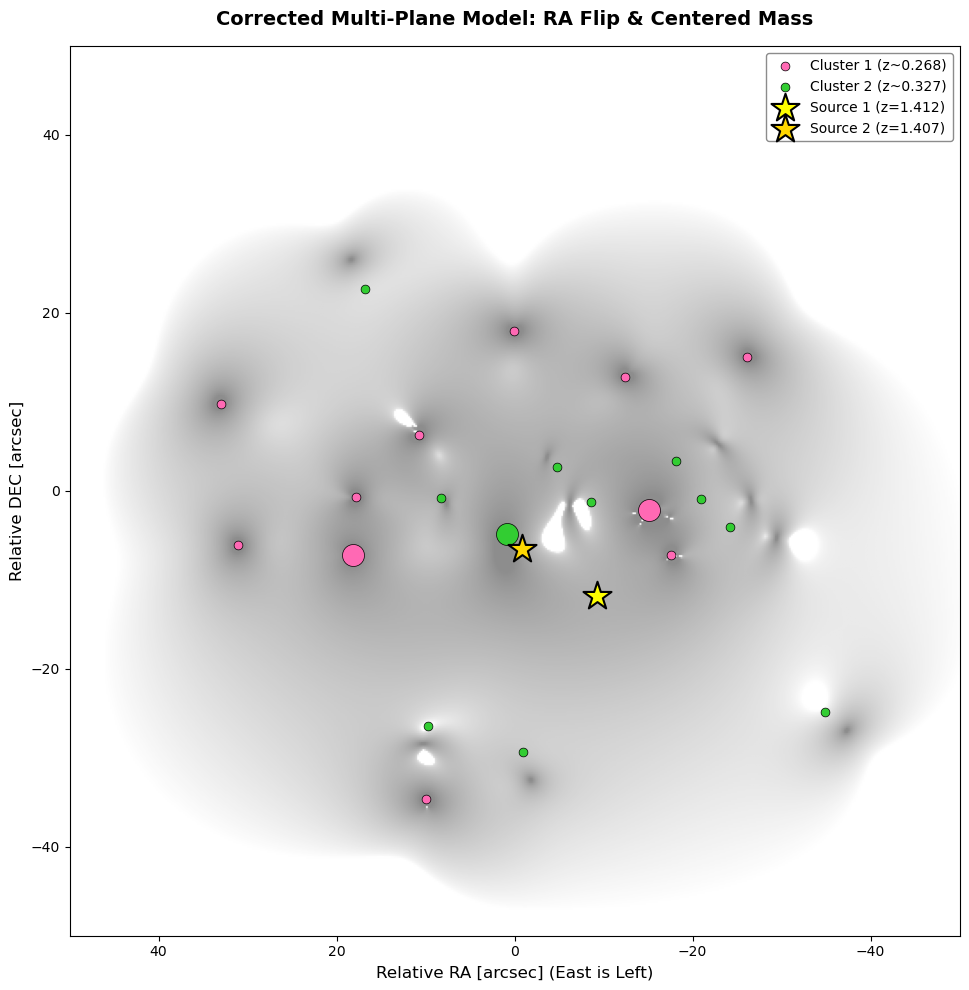

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Util import util

# ===========================================================================
# 1. LOAD AND TRANSFORM DATA
# ===========================================================================
c1 = pd.read_csv('cluster1.csv').sort_values('RAcen').reset_index(drop=True)
c2 = pd.read_csv('cluster2.csv').sort_values('RAcen').reset_index(drop=True)
s1 = pd.read_csv('system_1.412.csv')
# Keep only the first 5 lensed images of System 2 to match fig1.png
s2 = pd.read_csv('system_1.407.csv').iloc[:5]

ra_ref, dec_ref = 180.162, -1.451

def to_arcsec(ra, dec):
    x = (ra - ra_ref) * 3600 * np.cos(np.radians(dec_ref))
    y = (dec - dec_ref) * 3600
    return x, y

x_img1, y_img1 = to_arcsec(s1['RA'], s1['DEC'])
x_img2, y_img2 = to_arcsec(s2['RA'], s2['DEC'])

# ===========================================================================
# 2. SETUP MULTI-PLANE LENS MODEL
# ===========================================================================
lens_model_list = ['SERSIC'] * 22
lens_redshift_list = list(c1['Z']) + list(c2['Z'])

lensModel_s1 = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=1.412)
lensModel_s2 = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=1.407)

def get_kwargs_lens(params):
    k_m1, k_m2, k_m3, k_b1, k_b2 = params
    kwargs_lens = []
    
    # Plane 1: 3rd least (idx 2) and 3rd most (idx 8) are massive
    for i, row in c1.iterrows():
        x, y = to_arcsec(row['RAcen'], row['Deccen'])
        k, R_s = (k_m1, 3.5) if i == 2 else (k_m2, 3.5) if i == 8 else (k_b1, 0.8)
        kwargs_lens.append({'k_eff': k, 'R_sersic': R_s, 'n_sersic': 4.0, 'center_x': x, 'center_y': y})
        
    # Plane 2: 4th smallest RA (idx 3) is massive
    for i, row in c2.iterrows():
        x, y = to_arcsec(row['RAcen'], row['Deccen'])
        k, R_s = (k_m3, 3.0) if i == 7 else (k_b2, 0.6)
        kwargs_lens.append({'k_eff': k, 'R_sersic': R_s, 'n_sersic': 4.0, 'center_x': x, 'center_y': y})
    return kwargs_lens

# ===========================================================================
# 3. OBJECTIVE FUNCTION (Minimize Coordinate Spread)
# ===========================================================================
sigma_img = 0.004

def objective(params):
    if any(p <= 0 for p in params):
        return 1e10
    kwargs_lens = get_kwargs_lens(params)
    src1_ra, src1_dec = lensModel_s1.ray_shooting(x_img1, y_img1, kwargs_lens)
    src2_ra, src2_dec = lensModel_s2.ray_shooting(x_img2, y_img2, kwargs_lens)
    chi2_1 = (np.sum((src1_ra - np.mean(src1_ra))**2) + np.sum((src1_dec - np.mean(src1_dec))**2)) / (sigma_img**2)
    chi2_2 = (np.sum((src2_ra - np.mean(src2_ra))**2) + np.sum((src2_dec - np.mean(src2_dec))**2)) / (sigma_img**2)
    return 0.5 * (chi2_1 + chi2_2)

# ===========================================================================
# 4. TWO-STAGE GLOBAL + LOCAL OPTIMIZATION
# ===========================================================================
# Bounds defined as: [k_m1, k_m2, k_m3, k_b1, k_b2]
bounds = [(0.1, 5.0), (0.1, 5.0), (0.1, 5.0), (0.01, 2.0), (0.01, 2.0)]

print("--- STAGE 1: Differential Evolution Global Search (Avoids local minima) ---")
res_de = differential_evolution(objective, bounds, strategy='best1bin', maxiter=100, popsize=15, tol=1e-3, seed=42)

print("--- STAGE 2: BFGS Local Refinement ---")
res_opt = minimize(objective, res_de.x, method='BFGS', tol=1e-6)

# ===========================================================================
# 5. COMPUTE NUMERICAL HESSIAN FOR EXACT MASS UNCERTAINTIES
# ===========================================================================
def compute_hessian(func, x, eps=1e-3):
    n = len(x)
    hess = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                x_plus, x_minus = np.array(x, dtype=float), np.array(x, dtype=float)
                x_plus[i] += eps; x_minus[i] -= eps
                hess[i, i] = (func(x_plus) - 2 * func(x) + func(x_minus)) / (eps**2)
            else:
                x_pp, x_pm, x_mp, x_mm = [np.array(x, dtype=float) for _ in range(4)]
                x_pp[i] += eps; x_pp[j] += eps
                x_pm[i] += eps; x_pm[j] -= eps
                x_mp[i] -= eps; x_mp[j] += eps
                x_mm[i] -= eps; x_mm[j] -= eps
                hess[i, j] = (func(x_pp) - func(x_pm) - func(x_mp) + func(x_mm)) / (4 * eps**2)
    return hess

print("--- Calculating parameter uncertainties from the Hessian ---")
hessian_matrix = compute_hessian(objective, res_opt.x)
cov_matrix = np.linalg.inv(hessian_matrix)
uncertainties = np.sqrt(np.diag(cov_matrix))

# Extract results
k_m1, k_m2, k_m3, k_b1, k_b2 = res_opt.x
u_m1, u_m2, u_m3, u_b1, u_b2 = uncertainties
kwargs_lens_opt = get_kwargs_lens(res_opt.x)

# Recovered Source Positions and Residual Spreads
src1_ra_opt, src1_dec_opt = lensModel_s1.ray_shooting(x_img1, y_img1, kwargs_lens_opt)
src2_ra_opt, src2_dec_opt = lensModel_s2.ray_shooting(x_img2, y_img2, kwargs_lens_opt)
spread1_opt = np.sqrt(np.std(src1_ra_opt)**2 + np.std(src1_dec_opt)**2)
spread2_opt = np.sqrt(np.std(src2_ra_opt)**2 + np.std(src2_dec_opt)**2)

# ===========================================================================
# 6. PRINT RESULTS
# ===========================================================================
print("\n" + "="*45 + "\n=== OPTIMAL MASS DISTRIBUTION RESULTS ===\n" + "="*45)
print(f"Galaxy Cluster 1 Massive 1 (Galaxy 03): k_eff = {k_m1:.4f} ± {u_m1:.4f}")
print(f"Galaxy Cluster 1 Massive 2 (Galaxy 09): k_eff = {k_m2:.4f} ± {u_m2:.4f}")
print(f"Galaxy Cluster 2 Massive   (Galaxy 15): k_eff = {k_m3:.4f} ± {u_m3:.4f}")
print(f"Galaxy Cluster 1 Standard Galaxies:   k_eff = {k_b1:.4f} ± {u_b1:.4f}")
print(f"Galaxy Cluster 2 Standard Galaxies:   k_eff = {k_b2:.4f} ± {u_b2:.4f}")

print("\n" + "="*45 + "\n=== ORIGINAL SOURCE PLANE RECOVERED POSITIONS ===\n" + "="*45)
print(f"Source 1 (z=1.412) Recovered: RA_arcsec = {np.mean(src1_ra_opt):.4f}, Dec_arcsec = {np.mean(src1_dec_opt):.4f}")
print(f"Source 1 Residual Spread (arcsec): {spread1_opt:.5f}")
print(f"Source 2 (z=1.407) Recovered: RA_arcsec = {np.mean(src2_ra_opt):.4f}, Dec_arcsec = {np.mean(src2_dec_opt):.4f}")
print(f"Source 2 Residual Spread (arcsec): {spread2_opt:.5f}")

# ===========================================================================
# 7. GRAPHING
# ===========================================================================
limit = 50
res = 500
fig, ax = plt.subplots(figsize=(10, 10))

# Pre-calculate high-resolution mass map (kappa)
x_grid, y_grid = util.make_grid(numPix=res, deltapix=limit*2/res)
kappa_1d = lensModel_s1.kappa(x_grid, y_grid, kwargs_lens_opt)
kappa_2d = util.array2image(kappa_1d, nx=res, ny=res)

# Plot mass map background as grayscale - Clipped to 1e-5 to prevent negative log (NaN) white patches!
ax.imshow(np.log10(np.clip(kappa_2d, 1e-5, None)), origin='lower', cmap='gray_r', vmin=-3, vmax=1,
          extent=[-limit, limit, -limit, limit], alpha=0.45)

# Overlay Cluster 1 galaxies (hot pink, massive galaxies larger at indices 2 and 8)
for i, row in c1.iterrows():
    x, y = to_arcsec(row['RAcen'], row['Deccen'])
    size = 250 if i in [2, 8] else 40
    ax.scatter(x, y, color='hotpink', s=size, edgecolors='black', linewidths=0.5, label='Cluster 1 (z~0.268)' if i == 0 else "")

# Overlay Cluster 2 galaxies (limegreen, massive galaxy larger at index 3)
for i, row in c2.iterrows():
    x, y = to_arcsec(row['RAcen'], row['Deccen'])
    size = 250 if i == 7 else 40
    ax.scatter(x, y, color='limegreen', s=size, edgecolors='black', linewidths=0.5, label='Cluster 2 (z~0.327)' if i == 0 else "")

# Plot optimized original source plane positions (yellow stars with black borders)
ax.scatter(np.mean(src1_ra_opt), np.mean(src1_dec_opt), color='yellow', marker='*', s=450, edgecolors='black', 
           linewidths=1.5, zorder=5, label='Source 1 (z=1.412)')
ax.scatter(np.mean(src2_ra_opt), np.mean(src2_dec_opt), color='gold', marker='*', s=450, edgecolors='black', 
           linewidths=1.5, zorder=5, label='Source 2 (z=1.407)')

# Style configurations
ax.set_xlabel('Relative RA [arcsec] (East is Left)', fontsize=12)
ax.set_ylabel('Relative DEC [arcsec]', fontsize=12)
ax.set_title('Corrected Multi-Plane Model: RA Flip & Centered Mass', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(limit, -limit)  # FLIP X-AXIS FOR EAST IS LEFT (Positive values on left, negative on right)
ax.set_ylim(-limit, limit)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='gray', framealpha=0.9, fontsize=10)

plt.tight_layout()
plt.savefig('corrected_model_output.png', dpi=300)
plt.show()